# Model Training - Approach B: Angle Detection

This notebook trains a direct angle regression model to predict animal orientation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from pathlib import Path
import random
from tqdm.notebook import tqdm
import torchvision
import torchvision.transforms
import matplotlib.pyplot as plt

### Deleting old model


In [ ]:
import os
old_model = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_b.pth')
if old_model.exists():
    os.remove(old_model)
    print("Deleted old model weights")

Deleted old model weights


## Configuration

In [3]:
DATA_DIR     = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed')
LABELS_DIR   = PROCESSED_DIR / 'labels_keypoints'

TRAIN_IMG    = DATA_DIR / 'images' / 'train'
VAL_IMG      = DATA_DIR / 'images' / 'val'
TRAIN_LABELS = LABELS_DIR / 'train'
VAL_LABELS   = LABELS_DIR / 'val'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

IMG_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 50 # to get better results, increase to 30-50 epochs
LEARNING_RATE = 1e-4
NUM_KEYPOINTS = 2  # head and tail
WARMUP_EPOCHS  = 2       # epochs to train only the head before unfreezing backbone

Using device: cuda


Total training animals:  246
Mean head-tail dist:     0.0196
Median head-tail dist:   0.0174
% with dist < 0.05:      98.4%
% with dist < 0.02:      70.7%


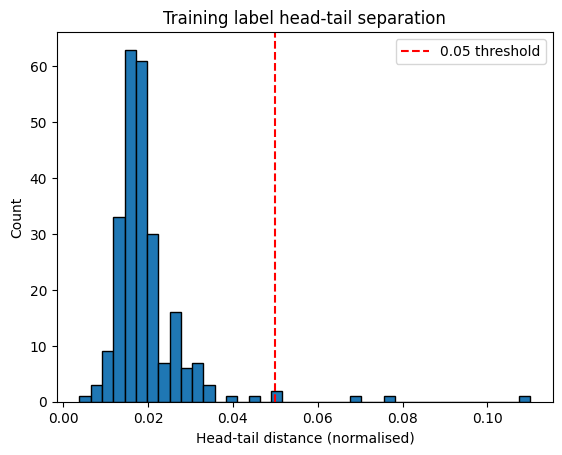

In [ ]:
# diagnostic: check head-tail distance distribution in training labels

distances = []
for label_file in TRAIN_LABELS.glob('*.txt'):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 11:
                head = np.array([float(parts[5]), float(parts[6])])
                tail = np.array([float(parts[8]), float(parts[9])])
                distances.append(np.linalg.norm(head - tail))

print(f"Total training animals:  {len(distances)}")
print(f"Mean head-tail dist:     {np.mean(distances):.4f}")
print(f"Median head-tail dist:   {np.median(distances):.4f}")
print(f"% with dist < 0.05:      {sum(d < 0.05 for d in distances)/len(distances)*100:.1f}%")
print(f"% with dist < 0.02:      {sum(d < 0.02 for d in distances)/len(distances)*100:.1f}%")

plt.hist(distances, bins=40, edgecolor='black')
plt.xlabel('Head-tail distance (normalised)')
plt.ylabel('Count')
plt.title('Training label head-tail separation')
plt.axvline(x=0.05, color='red', linestyle='--', label='0.05 threshold')
plt.legend()
plt.show()

## Dataset

In [ ]:
# dataset class to load images and keypoint labels
class KeypointDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform
        
        self.samples = []
        for label_file in sorted(self.label_dir.glob('*.txt')):
            img_file = self.img_dir / f"{label_file.stem}.jpg"
            if not img_file.exists():
                for split in ['train', 'val', 'test']:
                    candidate = self.img_dir.parent / split / f"{label_file.stem}.jpg"
                    if candidate.exists():
                        img_file = candidate
                        break
                else:
                    continue

            with open(label_file) as f:
                for i, line in enumerate(f):
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        self.samples.append((img_file, label_file, i))

        print(f"  Found {len(self.samples)} animal samples in {label_dir}")

    # return total number of samples
    def __len__(self):
        return len(self.samples)

    # load image, parse label for the specified animal, crop around it, and return image + keypoints
    def __getitem__(self, idx):
        img_file, label_file, animal_idx = self.samples[idx]
        
        img = Image.open(img_file).convert('RGB')
        orig_w, orig_h = img.size
        
        keypoints = torch.zeros(4, dtype=torch.float32)
        with open(label_file) as f:
            for i, line in enumerate(f):
                if i == animal_idx:
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        # Crop around bbox with padding
                        cx, cy = float(parts[1]), float(parts[2])
                        bw, bh = float(parts[3]), float(parts[4])
                        pad = 0.5

                        x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
                        y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
                        x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
                        y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

                        min_crop_px = orig_w * 0.10
                        if (x2 - x1) < min_crop_px:
                            mid_x = (x1 + x2) / 2
                            x1 = max(0, mid_x - min_crop_px / 2)
                            x2 = min(orig_w, mid_x + min_crop_px / 2)

                        min_crop_py = orig_h * 0.10    
                        if (y2 - y1) < min_crop_py:
                            mid_y = (y1 + y2) / 2
                            y1 = max(0, mid_y - min_crop_py / 2)
                            y2 = min(orig_h, mid_y + min_crop_py / 2)

                        crop_w = x2 - x1
                        crop_h = y2 - y1

                        img = img.crop((x1, y1, x2, y2))

                        head_x = max(0.0, min(1.0, (float(parts[5]) * orig_w - x1) / crop_w))
                        head_y = max(0.0, min(1.0, (float(parts[6]) * orig_h - y1) / crop_h))
                        tail_x = max(0.0, min(1.0, (float(parts[8]) * orig_w - x1) / crop_w))
                        tail_y = max(0.0, min(1.0, (float(parts[9]) * orig_h - y1) / crop_h))
                        
                        keypoints = torch.tensor(
                            [head_x, head_y, tail_x, tail_y],
                            dtype=torch.float32
                        )
                    break
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, keypoints

In [ ]:
# data augmentation: random horizontal and vertical flips with corresponding keypoint adjustments
class KeypointDatasetWithFlip(KeypointDataset):
    def __getitem__(self, idx):
        img_file, label_file, animal_idx = self.samples[idx]
        
        img = Image.open(img_file).convert('RGB')
        orig_w, orig_h = img.size
        
        angle_target = torch.zeros(2, dtype=torch.float32)  # (sin, cos) of angle
        
        with open(label_file) as f:
            for i, line in enumerate(f):
                if i == animal_idx:
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        cx, cy = float(parts[1]), float(parts[2])
                        bw, bh = float(parts[3]), float(parts[4])
                        pad = 0.5

                        x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
                        y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
                        x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
                        y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

                        min_crop_px = orig_w * 0.10
                        if (x2 - x1) < min_crop_px:
                            mid_x = (x1 + x2) / 2
                            x1 = max(0, mid_x - min_crop_px / 2)
                            x2 = min(orig_w, mid_x + min_crop_px / 2)

                        min_crop_py = orig_h * 0.10
                        if (y2 - y1) < min_crop_py:
                            mid_y = (y1 + y2) / 2
                            y1 = max(0, mid_y - min_crop_py / 2)
                            y2 = min(orig_h, mid_y + min_crop_py / 2)

                        img = img.crop((x1, y1, x2, y2))

                        # Compute angle from head to tail
                        hx = float(parts[5]) * orig_w
                        hy = float(parts[6]) * orig_h
                        tx = float(parts[8]) * orig_w
                        ty = float(parts[9]) * orig_h

                        dx = hx - tx
                        dy = hy - ty
                        angle = np.arctan2(dy, dx)

                        # encode as (sin, cos) so the output is continuous
                        # and 180° ambiguity is handled naturally
                        angle_target = torch.tensor(
                            [np.sin(angle), np.cos(angle)],
                            dtype=torch.float32
                        )
                    break

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, angle_target

In [ ]:
# data augmentation for limited real data
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# load datasets and create dataloaders
train_dataset = KeypointDatasetWithFlip(TRAIN_IMG, TRAIN_LABELS, transform=train_transform)
val_dataset   = KeypointDatasetWithFlip(VAL_IMG,   VAL_LABELS,   transform=val_transform)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# warn if suspiciously empty
if len(train_dataset) == 0:
    raise RuntimeError("No training samples found! Check TRAIN_IMG and TRAIN_LABELS paths.")
if len(val_dataset) == 0:
    raise RuntimeError("No validation samples found! Check VAL_IMG and VAL_LABELS paths.")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

  Found 246 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train
  Found 52 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val
Training samples:   246
Validation samples: 52


In [ ]:
# sanity check before training

print("=== Path check ===")
print(f"TRAIN_IMG exists:    {TRAIN_IMG.exists()}  ({TRAIN_IMG})")
print(f"VAL_IMG exists:      {VAL_IMG.exists()}  ({VAL_IMG})")
print(f"TRAIN_LABELS exists: {TRAIN_LABELS.exists()}  ({TRAIN_LABELS})")
print(f"VAL_LABELS exists:   {VAL_LABELS.exists()}  ({VAL_LABELS})")

print("\n=== Sample batch check ===")
imgs, kps = next(iter(train_loader))
print(f"Image batch shape:    {imgs.shape}")
print(f"Keypoints batch shape:{kps.shape}")
print(f"Keypoints sample:     {kps[0]}")
print(f"All zeros in batch?   {(kps == 0).all().item()}  <- should be False")

=== Path check ===
TRAIN_IMG exists:    True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train)
VAL_IMG exists:      True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/val)
TRAIN_LABELS exists: True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train)
VAL_LABELS exists:   True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val)

=== Sample batch check ===
Image batch shape:    torch.Size([8, 3, 256, 256])
Keypoints batch shape:torch.Size([8, 2])
Keypoints sample:     tensor([-0.1240, -0.9923])
All zeros in batch?   False  <- should be False


## Model

In [ ]:
# sanity check model forward pass
class KeypointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # sin and cos of angle
        )

    def forward(self, x):
        out = self.backbone(x)
        # normalise to unit vector so output is always a valid angle
        return nn.functional.normalize(out, dim=1)

model = KeypointModel().to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,001,122


## Training

In [ ]:
# angle loss function that compares predicted and true angles
def angle_loss(outputs, targets):
    cos_sim = (outputs * targets).sum(dim=1)
    return (1 - cos_sim).mean()

# evaluation function to compute angular error metrics
def evaluate_angle(model, loader, device):
    model.eval()
    errors_deg = []
    with torch.no_grad():
        for imgs, targets in loader:
            imgs    = imgs.to(device)
            targets = targets.to(device)
            preds   = model(imgs)
            pred_angles = torch.atan2(preds[:,0],  preds[:,1])
            true_angles = torch.atan2(targets[:,0], targets[:,1])
            diff = (pred_angles - true_angles).abs()
            diff = torch.min(diff, 2 * np.pi - diff)
            diff = torch.min(diff, np.pi - diff)
            errors_deg.extend((diff * 180 / np.pi).cpu().numpy())
    errors_deg = np.array(errors_deg)
    print(f"  Mean angular error:   {errors_deg.mean():.1f}°")
    print(f"  Median angular error: {np.median(errors_deg):.1f}°")
    print(f"  % within 30°:         {(errors_deg < 30).mean()*100:.1f}%")
    print(f"  % within 45°:         {(errors_deg < 45).mean()*100:.1f}%")
    print(f"  % within 90°:         {(errors_deg < 90).mean()*100:.1f}%")
    return errors_deg

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=15, factor=0.5)

# freeze backbone for warmup epochs so the new head stabilises first
print(f"Freezing backbone for first {WARMUP_EPOCHS} warmup epochs...")
for param in model.backbone.parameters():
    param.requires_grad = False
# keep new head trainable
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

Freezing backbone for first 2 warmup epochs...


In [ ]:
print(val_dataset.samples[0])  # should show 3 values: (img, label, animal_idx)

# baseline: always predict 0° (pointing right)
dummy_preds       = torch.zeros(len(val_dataset), 2)
dummy_preds[:, 1] = 1.0  # cos(0°)=1, sin(0°)=0
dummy_targets     = torch.stack([val_dataset[i][1] for i in range(len(val_dataset))])

baseline_loss = angle_loss(dummy_preds, dummy_targets)
print(f"Baseline loss (always predict 0°): {baseline_loss:.4f}")

print(f"\nTarget statistics (sin, cos):")
print(f"  Mean: {dummy_targets.mean(dim=0)}")
print(f"  Std:  {dummy_targets.std(dim=0)}")
print(f"  Min:  {dummy_targets.min(dim=0).values}")
print(f"  Max:  {dummy_targets.max(dim=0).values}")

print(f"\nSample angle targets from val set:")
for i in range(5):
    _, kp = val_dataset[i]
    angle_deg = np.degrees(np.arctan2(kp[0].item(), kp[1].item()))
    print(f"  sin={kp[0]:.3f} cos={kp[1]:.3f}  →  {angle_deg:.1f}°")

(PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train/115_5577.jpg'), PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5577.txt'), 0)
Baseline loss (always predict 0°): 1.2186

Target statistics (sin, cos):
  Mean: tensor([ 0.1130, -0.2186])
  Std:  tensor([0.8028, 0.5598])
  Min:  tensor([-0.9994, -0.9859])
  Max:  tensor([0.9980, 0.9795])

Sample angle targets from val set:
  sin=-0.782 cos=-0.623  →  -128.6°
  sin=-0.593 cos=-0.805  →  -143.6°
  sin=-0.964 cos=-0.268  →  -105.5°
  sin=-0.919 cos=-0.394  →  -113.2°
  sin=0.841 cos=-0.541  →  122.7°


In [ ]:
# training loop with validation and model saving
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs    = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = angle_loss(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# validation function to compute average loss on validation set
def validate(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs    = imgs.to(device)
            targets = targets.to(device)
            outputs = model(imgs)
            loss = angle_loss(outputs, targets)
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
# look at the raw label file content
label_file = val_dataset.samples[0][1]
print(f"File: {label_file}")
print(f"\nRaw content:")
with open(label_file) as f:
    for line in f:
        print(f"  {line.strip()}")
        parts = line.strip().split()
        if len(parts) >= 11:
            print(f"    class={parts[0]}")
            print(f"    bbox:  cx={parts[1]}, cy={parts[2]}, w={parts[3]}, h={parts[4]}")
            print(f"    head:  x={parts[5]}, y={parts[6]}, vis={parts[7]}")
            print(f"    tail:  x={parts[8]}, y={parts[9]}, vis={parts[10]}")

File: /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5577.txt

Raw content:
  28 0.3876953125 0.200439453125 0.03515625 0.03564453125 0.385882 0.190133 1 0.402589 0.211093 1
    class=28
    bbox:  cx=0.3876953125, cy=0.200439453125, w=0.03515625, h=0.03564453125
    head:  x=0.385882, y=0.190133, vis=1
    tail:  x=0.402589, y=0.211093, vis=1


In [ ]:
# training loop with validation and model saving
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

MODEL_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(NUM_EPOCHS):

    if epoch == WARMUP_EPOCHS:
        print(f"\nEpoch {epoch+1}: Unfreezing backbone with lower LR...")
        for param in model.backbone.parameters():
            param.requires_grad = True
        for g in optimizer.param_groups:
            g['lr'] = LEARNING_RATE * 0.1

    train_loss = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = validate(model, val_loader, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / 'best_keypoint_model_B.pth')
        print(f"  -> Saved best model!")

Epoch 1/50 - Train Loss: 0.8448, Val Loss: 0.7118
  -> Saved best model!
Epoch 2/50 - Train Loss: 0.7721, Val Loss: 0.6950
  -> Saved best model!

Epoch 3: Unfreezing backbone with lower LR...
Epoch 3/50 - Train Loss: 0.7689, Val Loss: 0.6858
  -> Saved best model!
Epoch 4/50 - Train Loss: 0.7345, Val Loss: 0.6913
Epoch 5/50 - Train Loss: 0.7562, Val Loss: 0.6928
Epoch 6/50 - Train Loss: 0.7154, Val Loss: 0.6940
Epoch 7/50 - Train Loss: 0.6973, Val Loss: 0.6893
Epoch 8/50 - Train Loss: 0.7033, Val Loss: 0.6861
Epoch 9/50 - Train Loss: 0.6990, Val Loss: 0.6742
  -> Saved best model!
Epoch 10/50 - Train Loss: 0.6884, Val Loss: 0.6622
  -> Saved best model!
Epoch 11/50 - Train Loss: 0.6983, Val Loss: 0.6519
  -> Saved best model!
Epoch 12/50 - Train Loss: 0.6709, Val Loss: 0.6394
  -> Saved best model!
Epoch 13/50 - Train Loss: 0.6507, Val Loss: 0.6284
  -> Saved best model!
Epoch 14/50 - Train Loss: 0.6396, Val Loss: 0.6248
  -> Saved best model!
Epoch 15/50 - Train Loss: 0.6435, Val Los

#### Check if it actually trained

In [16]:
model.eval()
print("\nSample predictions vs targets (angles):")
imgs, kps = next(iter(val_loader))
with torch.no_grad():
    preds = model(imgs.to(DEVICE)).cpu()

for i in range(5):
    p = preds[i].numpy()
    t = kps[i].numpy()
    pred_deg = np.degrees(np.arctan2(p[0], p[1]))
    true_deg = np.degrees(np.arctan2(t[0], t[1]))
    diff = abs(pred_deg - true_deg)
    diff = min(diff, 360 - diff, 180 - abs(diff - 180))
    print(f"  pred={pred_deg:.1f}°  true={true_deg:.1f}°  err={diff:.1f}°")

print()
evaluate_angle(model, val_loader, DEVICE)


Sample predictions vs targets (angles):
  pred=-138.3°  true=-128.6°  err=9.7°
  pred=-161.1°  true=-143.6°  err=17.5°
  pred=126.3°  true=-105.5°  err=128.2°
  pred=148.7°  true=-113.2°  err=98.1°
  pred=151.4°  true=122.7°  err=28.7°



  Mean angular error:   35.8°
  Median angular error: 32.0°
  % within 30°:         48.1%
  % within 45°:         65.4%
  % within 90°:         100.0%


array([ 9.715452 , 17.461761 , 51.809235 , 81.8801   , 28.687683 ,
       33.488388 , 66.320015 , 52.888393 , 62.181637 , 58.619633 ,
        8.01886  , 14.058113 , 36.48469  , 14.384146 , 22.267355 ,
       16.316528 , 33.249264 ,  0.7015902, 72.208824 , 27.253479 ,
       10.364142 , 11.594724 , 58.001934 , 35.35172  , 79.379654 ,
       16.347197 , 13.30831  , 53.813477 , 38.543343 , 51.90686  ,
       24.119623 ,  4.250249 ,  9.631304 , 77.96111  , 26.03526  ,
        6.0425587,  2.1719522, 30.752434 , 13.8130045, 59.57451  ,
       56.85548  ,  6.980357 , 40.4036   , 78.836    , 73.28527  ,
       71.75113  , 29.213667 , 25.915308 , 20.440002 , 33.559082 ,
       36.078186 , 55.813835 ], dtype=float32)

## Training Curves

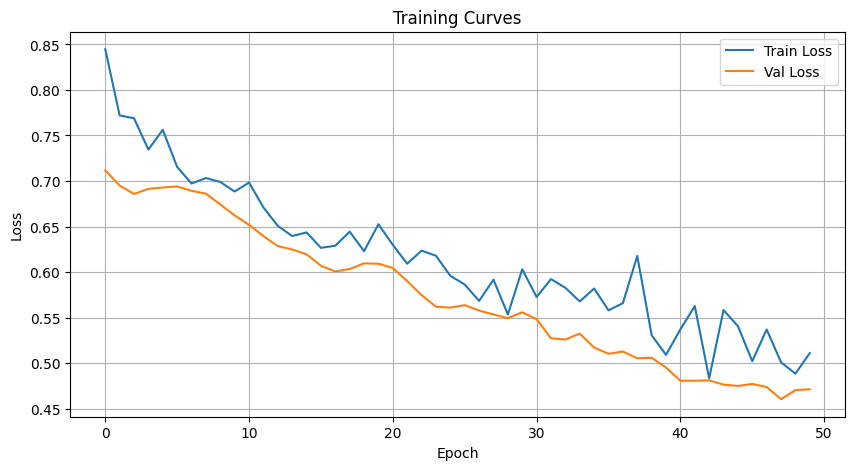

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.show()